#### Notebook to analyze videos to find contours across an entire duration

In [1]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed

In [2]:
# ---- Pipeline Configuration ----
# Set all paths and filenames here for easy reuse

# Experiment ID (used in filenames)
exp_id = "11oct2025" #Also change date in base_dir below
treatment = "DD_T1"

# Base directories
base_dir = f"/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/11Oct25/{exp_id}_{treatment}"
results_dir = "../../results/"
scripts_dir = "../../scripts/"

# Video pattern and output files
video_pattern = f"{base_dir}/{exp_id}_{treatment}_part???.mp4"
output_file = f"{results_dir}contours_{exp_id}_{treatment}.tab"

# Visualization parameters
black = 110
minArea = 1.5
maxArea = 1000.0
brightnessThreshold = 50
threads = 4
maxy = None

### First find the video and frame number where the lights turn off

In [4]:
# This uses ffmpeg to determine when the lights go off in the video.
#
# black frame is defined by ffmpeg's blackdetect filter with these parameters:
# d=0.5: The minimum duration (in seconds) for a black segment to be detected.
# pix_th=0.10: The pixel threshold; a frame is considered "black" if at least 90% of its pixels have a luma (brightness) value below the default threshold (default is 32 out of 255).
# So, a black frame is one where at least 90% of its pixels are very dark (luma < 32), and a black segment is reported if this condition lasts for at least 0.5 seconds.

import subprocess
import cv2
import re
import pandas as pd
import os

video_path = f"{base_dir}/{exp_id}_{treatment}_part3.mp4"  # Use global base_dir and exp_id

print("Video path:", video_path)
print("File exists:", os.path.exists(video_path))

# ffmpeg blackdetect
cmd = (
    f'ffmpeg -hide_banner -nostats -i "{video_path}" '
    '-vf "blackdetect=d=0.5:pix_th=0.10" -an -f null - 2>&1 | grep "black_start" | tail -1'
)
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
line = result.stdout.strip()

# Extract blackdetect times
match = re.search(r'black_start:(\d+\.\d+)\s+black_end:(\d+\.\d+)\s+black_duration:(\d+\.?\d*)', line)
if match:
    black_start = float(match.group(1))
    black_end = float(match.group(2))
    black_duration = float(match.group(3))
else:
    black_start = black_end = black_duration = None

# OpenCV video info
cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
total_length = frame_count / fps if fps else None

def sec_to_mmss(seconds):
    if seconds is None:
        return ""
    m, s = divmod(int(seconds), 60)
    return f"{m:02d}:{s:02d}"

def sec_to_frame(seconds, fps):
    if seconds is None or not fps:
        return ""
    return int(round(seconds * fps))

table = [
    {"event": "total_length", "frame": frame_count, "time (mm:ss)": sec_to_mmss(total_length)},
    {"event": "blackstart", "frame": sec_to_frame(black_start, fps), "time (mm:ss)": sec_to_mmss(black_start)},
    {"event": "blackend", "frame": sec_to_frame(black_end, fps), "time (mm:ss)": sec_to_mmss(black_end)},
    {"event": "blackduration", "frame": sec_to_frame(black_duration, fps), "time (mm:ss)": sec_to_mmss(black_duration)},
]

darkness = pd.DataFrame(table)

Video path: /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/11Oct25/11oct2025_DD_T1/11oct2025_DD_T1_part3.mp4
File exists: True


In [5]:
print("Video Information")
print(f"FPS: {fps}")
print(f"Video duration (s): {total_length}")
print(darkness)
print("\n")


Video Information
FPS: 10.0
Video duration (s): 1800.1
           event  frame time (mm:ss)
0   total_length  18001        30:00
1     blackstart                    
2       blackend                    
3  blackduration                    




### Here, manually find borders of tanks

Figure(640x480)


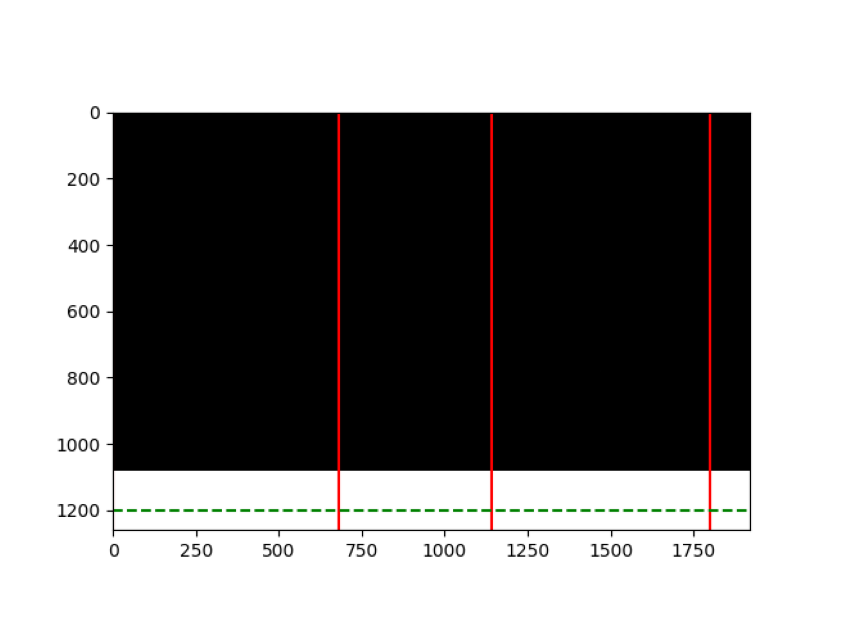

In [9]:
import subprocess
import matplotlib.pyplot as plt
import cv2
import os

# Manually iterate these numbers to identify borders of tanks
x_lines = [0, 680, 1140, 1800]
y_lines = [0, 1200]

# Extract xlim and ylim from x_lines and y_lines from manual numbers above
xlim = [x_lines[0], x_lines[-1]]
ylim = [y_lines[0], y_lines[-1]]

# Parameters
video_path = f"{base_dir}/{exp_id}_{treatment}_part1.mp4"  # Use global base_dir and exp_id
frame_number = 500
output_image = f"{results_dir}{exp_id}_{treatment}.png"  # Use global results_dir and exp_id

# Build command
cmd = [
    'python3', f'{scripts_dir}visualize_tanx.py',
    '-v', video_path,
    '-f', str(frame_number),
    '-t', *map(str, x_lines),
    '-y', *map(str, y_lines),
    '-o', output_image
]

# Run the script
subprocess.run(cmd, check=True)

# Display the image in the notebook
if os.path.exists(output_image):
    img = cv2.imread(output_image)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print('Visualization image not found.')

In [ ]:
# Rename video parts to zero-padded 3-digit format (dry-run by default)
import os
import re
from pathlib import Path

do_apply = False  # Set to True to perform renames False just prints text to screen

# Use notebook variables if defined, else edit this path
try:
    base_dir  # noqa: F821
except NameError:
    base_dir = "/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/11Oct25/11oct2025_DD_T1"  # <--- change if needed


pattern = re.compile(r"^(.*_part)(\d{1,3})(\.mp4)$")

p = Path(base_dir)
if not p.exists():
    raise FileNotFoundError(f"Base directory not found: {base_dir}")

# Collect files that match *_partN.mp4 (1- to 3-digit)
files = [f for f in sorted(p.iterdir()) if f.is_file() and f.name.endswith('.mp4') and '_part' in f.name]

renames = []
for src in files:
    m = pattern.match(src.name)
    if not m:
        continue
    prefix, num_s, suffix = m.groups()
    num = int(num_s)
    target_name = f"{prefix}{num:03d}{suffix}"
    target = src.parent / target_name
    # Skip if already correct
    if src.name == target_name:
        continue
    renames.append((src, target))

if not renames:
    print('No files to rename.')
else:
    print(f"Planned {len(renames)} renames (apply={do_apply}):")
    for s, d in renames:
        print(f"  {s.name} -> {d.name}")

    if do_apply:
        # Safety: ensure we don't overwrite existing targets
        conflicts = [d for _, d in renames if d.exists()]
        if conflicts:
            print('Refusing to run because some target filenames already exist:')
            for c in conflicts:
                print('  ', c.name)
            raise FileExistsError('One or more target filenames already exist. Resolve conflicts or remove files before running with do_apply=True')

        # Perform renames
        for s, d in renames:
            print(f"Renaming {s.name} -> {d.name}")
            s.rename(d)
        print('Renaming complete.')

Planned 99 renames (apply=True):
  11oct2025_DD_T1_part1.mp4 -> 11oct2025_DD_T1_part001.mp4
  11oct2025_DD_T1_part10.mp4 -> 11oct2025_DD_T1_part010.mp4
  11oct2025_DD_T1_part11.mp4 -> 11oct2025_DD_T1_part011.mp4
  11oct2025_DD_T1_part12.mp4 -> 11oct2025_DD_T1_part012.mp4
  11oct2025_DD_T1_part13.mp4 -> 11oct2025_DD_T1_part013.mp4
  11oct2025_DD_T1_part14.mp4 -> 11oct2025_DD_T1_part014.mp4
  11oct2025_DD_T1_part15.mp4 -> 11oct2025_DD_T1_part015.mp4
  11oct2025_DD_T1_part16.mp4 -> 11oct2025_DD_T1_part016.mp4
  11oct2025_DD_T1_part17.mp4 -> 11oct2025_DD_T1_part017.mp4
  11oct2025_DD_T1_part18.mp4 -> 11oct2025_DD_T1_part018.mp4
  11oct2025_DD_T1_part19.mp4 -> 11oct2025_DD_T1_part019.mp4
  11oct2025_DD_T1_part2.mp4 -> 11oct2025_DD_T1_part002.mp4
  11oct2025_DD_T1_part20.mp4 -> 11oct2025_DD_T1_part020.mp4
  11oct2025_DD_T1_part21.mp4 -> 11oct2025_DD_T1_part021.mp4
  11oct2025_DD_T1_part22.mp4 -> 11oct2025_DD_T1_part022.mp4
  11oct2025_DD_T1_part23.mp4 -> 11oct2025_DD_T1_part023.mp4
  11oct20

In [10]:
import os
script_path = os.path.abspath("../../scripts/find_contours.py")
maxy = None  # or an integer
xlim_arg = f"--xlim {xlim[0]} {xlim[1]}"
ylim_arg = f"--ylim {ylim[0]} {ylim[1]}"
maxy_arg = f"--maxy {maxy}" if maxy is not None else ""
# FIX: Use --pattern instead of --video_pattern in CLI command
cmd = (
    f"python3 {script_path} "
    f"--pattern \"{video_pattern}\" "
    f"-b {black} "
    f"--minarea {minArea} "
    f"--maxarea {maxArea} "
    f"--brightness {brightnessThreshold} "
    f"-t {threads} "
    f"-o \"{output_file}\" "
    f"{maxy_arg} "
    f"{xlim_arg} "
    f"{ylim_arg}"
)
print("Run this command in your terminal:\n\n")
print(cmd)

Run this command in your terminal:


python3 /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/lunar/scripts/find_contours.py --pattern "/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/11Oct25/11oct2025_DD_T1/11oct2025_DD_T1_part??.mp4" -b 110 --minarea 1.5 --maxarea 1000.0 --brightness 50 -t 4 -o "../../results/contours_11oct2025_DD_T1.tab"  --xlim 0 1800 --ylim 0 1200


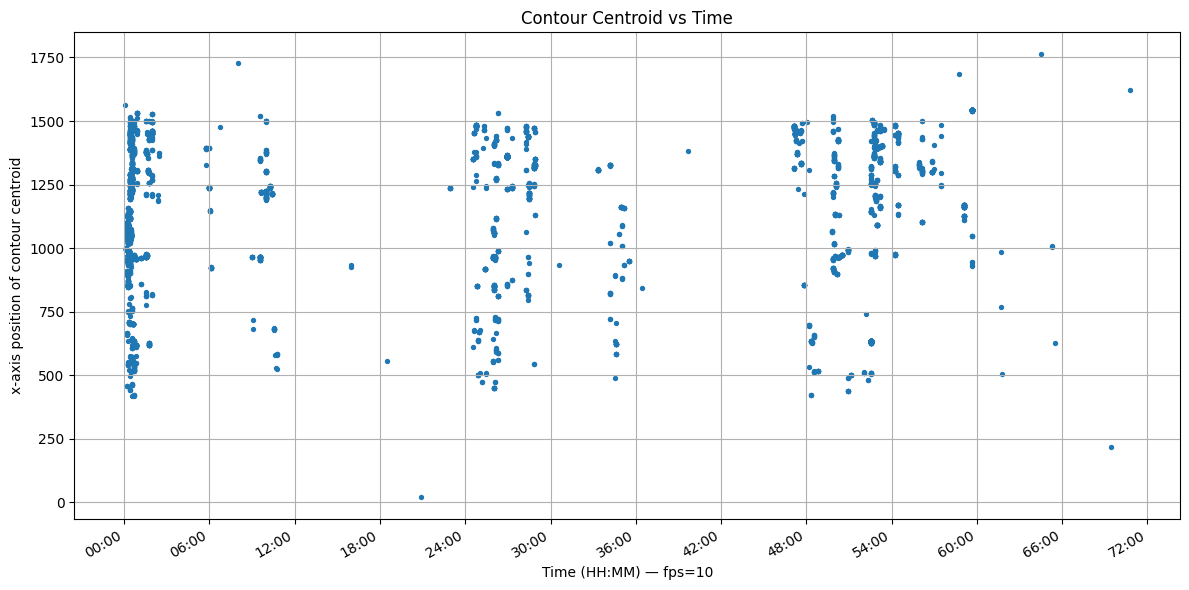

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

# Adjustable parameters
fps = 10              # frames per second (change as needed)
hour_tick = 6         # major tick spacing in hours

# Load the tab-separated file (uses existing `output_file` variable from notebook)
df = pd.read_csv(output_file, sep='\t')

# Convert frames -> seconds -> hours
df['time_s'] = df['frame'] / fps
df['time_h'] = df['time_s'] / 3600.0   # hours

# Plot time (hours) vs cX
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df['time_h'], df['cX'], s=8)
ax.set_xlabel(f'Time (HH:MM) — fps={fps}')
ax.set_ylabel('x-axis position of contour centroid')
ax.set_title('Contour Centroid vs Time')

# Formatter: convert hours (float) to HH:MM string
def hours_to_hhmm(x, pos):
    total_seconds = int(round(x * 3600))
    h = total_seconds // 3600
    m = (total_seconds % 3600) // 60
    return f"{h:02d}:{m:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))
ax.xaxis.set_major_locator(MultipleLocator(hour_tick))

# Rotate labels to avoid overlap and tighten layout
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
ax.grid(True)
plt.show()